In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# angle data
angles_df_backward = pd.read_csv('angles_df_backward.csv')
angles_df_forward = pd.read_csv('angles_df_forward.csv')

In [3]:
color_red = '#E89DA0'
color_blue = '#88CEE6'

if the p-value is larger than 0.05, the correlation is not significant
Compare time_on_hole and angle_change
Pearson correlation coefficient: -0.043, p-value: 0.784
Compare time_on_hole and Angle_before_entry
Pearson correlation coefficient: -0.104, p-value: 0.508
Compare time_on_hole and Angle_after_entry
Pearson correlation coefficient: 0.108, p-value: 0.489


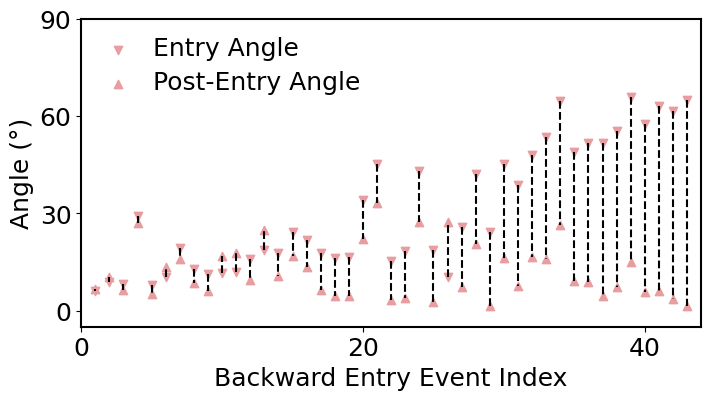

In [4]:
import matplotlib.pyplot as plt

# Filter and reindex
angles_df_plot = angles_df_backward
# Calculate angle change
angles_df_plot['Angle_change'] = np.abs(angles_df_plot['Angle_before_entry'] - (180 - angles_df_plot['Angle_after_entry']))
# angles_df_plot['new_Index'] = range(1, angles_df_plot.shape[0] + 1)
# sort by angle change
angles_df_plot = angles_df_plot.sort_values(by='Angle_change', ascending=True)
angles_df_plot['new_Index'] = range(1, angles_df_plot.shape[0] + 1)

# Colors and shapes
# color_before = '#C75055'  # Red for before entry
# color_after = '#D07F7A'   # Lighter red for after entry
color_before = '#E89DA0' 
color_after = '#E89DA0'  
color_time = 'gray'       # Gray for time on hole
color_line = 'black'      # Black for connection lines

# shape_before = 'x'        # X marker for before entry
# shape_before = '^'        # Triangle marker for before entry
shape_before = 'v'        # Inverted triangle marker for before entry
shape_after = 'o'         # Circle marker for after entry
shape_after = '^'         # Triangle marker for after entry
shape_time = 's'          # Square marker for time on hole

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(8, 4))

# Scatter plot for entry angles
scatter_before = ax1.scatter(angles_df_plot['new_Index'], angles_df_plot['Angle_before_entry'], 
                             label='Entry Angle', marker=shape_before, color=color_before)
scatter_after = ax1.scatter(angles_df_plot['new_Index'], 180 - angles_df_plot['Angle_after_entry'], 
                            label='Post-Entry Angle', marker=shape_after, color=color_after)

# Draw dashed lines connecting points
for i in range(angles_df_plot.shape[0]):
    ax1.plot([angles_df_plot['new_Index'].iloc[i], angles_df_plot['new_Index'].iloc[i]], 
             [angles_df_plot['Angle_before_entry'].iloc[i], 180 - angles_df_plot['Angle_after_entry'].iloc[i]], 
             '--', color=color_line)

# Labels and limits
ax1.set_xlabel("Backward Entry Event Index")
ax1.set_ylabel("Angle (\u00b0)")
# ax1.set_ylim(-15, 90)
ax1.set_ylim(-5, 90)
ax1.set_xlim(0, angles_df_plot.shape[0] + 1)

ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=12)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=6)
# set y-axis ticks
ax.set_yticks(np.arange(0, 91, 30))
ax.locator_params(axis='x', nbins=6)


# # Create secondary y-axis
# ax2 = ax1.twinx()
# # # just dots for time on hole
# # line_time = ax2.scatter(angles_df_plot['new_Index'], angles_df_plot['Time_on_hole'], 
# #                       label='Aperture Transit Time', marker=shape_time, color=color_time)
# line_time, = ax2.plot(angles_df_plot['new_Index'], angles_df_plot['Time_on_hole'],
#                         label='Aperture Transit Time', marker=shape_time, color=color_time )

# ax2.set_ylabel("Transit Time (s)", rotation=270, labelpad=15)
# ax2.set_ylim(0, 4)

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
# # handles2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(handles=handles1 + [line_time], labels=labels1 + ["Aperture Transit Time"], loc='upper left', frameon=False, 
#            fontsize=14)
ax1.legend(handles=handles1, labels=labels1, loc='upper left', frameon=False, 
           fontsize=14)

ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(18)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=6)
# ax.locator_params(axis='x', nbins=6)
# set x-axis ticks
ax.set_xticks([0, 20, 40])

# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('Backward_entry_angle_details_angle_only.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
from scipy.stats import pearsonr
# notes
print("if the p-value is larger than 0.05, the correlation is not significant")
# compare time_on_hole and angle_change
r, p_value = pearsonr(angles_df_plot["Time_on_hole"], angles_df_plot["Angle_change"])
print ("Compare time_on_hole and angle_change")
print(f"Pearson correlation coefficient: {r:.3f}, p-value: {p_value:.3f}")
# compare time_on_hole and Angle_before_entry
r, p_value = pearsonr(angles_df_plot["Time_on_hole"], angles_df_plot["Angle_before_entry"])
print ("Compare time_on_hole and Angle_before_entry")
print(f"Pearson correlation coefficient: {r:.3f}, p-value: {p_value:.3f}")
# compare time_on_hole and Angle_after_entry
r, p_value = pearsonr(angles_df_plot["Time_on_hole"], angles_df_plot["Angle_after_entry"])
print ("Compare time_on_hole and Angle_after_entry")
print(f"Pearson correlation coefficient: {r:.3f}, p-value: {p_value:.3f}")

if the p-value is larger than 0.05, the correlation is not significant
Compare time_on_hole and angle_change
Pearson correlation coefficient: 0.262, p-value: 0.177
Compare time_on_hole and Angle_before_entry
Pearson correlation coefficient: 0.073, p-value: 0.712
Compare time_on_hole and Angle_after_entry
Pearson correlation coefficient: -0.223, p-value: 0.254


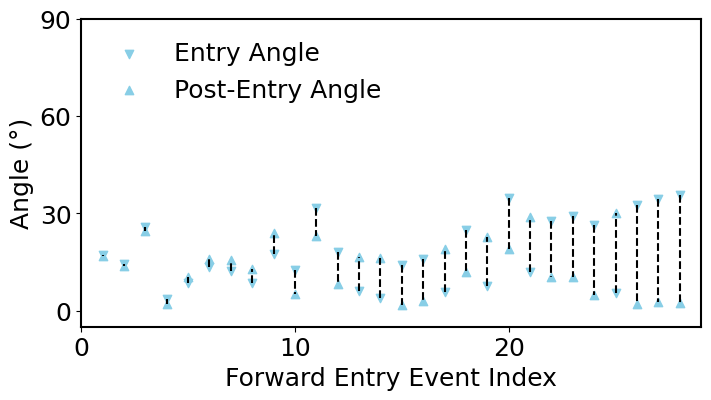

In [5]:
import matplotlib.pyplot as plt

# Filter and reindex
angles_df_plot = angles_df_forward
# Calculate angle change
angles_df_plot['Angle_change'] = np.abs(angles_df_plot['Angle_before_entry'] - (180 - angles_df_plot['Angle_after_entry']))
# angles_df_plot['new_Index'] = range(1, angles_df_plot.shape[0] + 1)
# sort by angle change
angles_df_plot = angles_df_plot.sort_values(by='Angle_change', ascending=True)
angles_df_plot['new_Index'] = range(1, angles_df_plot.shape[0] + 1)

# Colors and shapes
# color_before = '#4292C6'  # Blue for before entry
# color_after = '#9ECae1'  # Lighter blue for after entry
color_before = '#88CEE6'
color_after = '#88CEE6'
color_time = 'gray'       # Gray for time on hole
color_line = 'black'      # Black for connection lines

# shape_before = 'x'        # X marker for before entry
# shape_before = '^'        # Triangle marker for before entry
shape_before = 'v'        # Inverted triangle marker for before entry
shape_after = 'o'         # Circle marker for after entry
shape_after = '^'         # Triangle marker for after entry
shape_time = 's'          # Square marker for time on hole

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(8, 4))

# Scatter plot for entry angles
scatter_before = ax1.scatter(angles_df_plot['new_Index'], angles_df_plot['Angle_before_entry'], 
                             label='Entry Angle', marker=shape_before, color=color_before)
scatter_after = ax1.scatter(angles_df_plot['new_Index'], 180 - angles_df_plot['Angle_after_entry'], 
                            label='Post-Entry Angle', marker=shape_after, color=color_after)

# Draw dashed lines connecting points
for i in range(angles_df_plot.shape[0]):
    ax1.plot([angles_df_plot['new_Index'].iloc[i], angles_df_plot['new_Index'].iloc[i]], 
             [angles_df_plot['Angle_before_entry'].iloc[i], 180 - angles_df_plot['Angle_after_entry'].iloc[i]], 
             '--', color=color_line)

# Labels and limits
ax1.set_xlabel("Forward Entry Event Index")
ax1.set_ylabel("Angle (\u00b0)")
# ax1.set_ylim(-15, 90)
ax1.set_ylim(-5, 90)
ax1.set_xlim(0, angles_df_plot.shape[0] + 1)

ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=12)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=6)
# set y-axis ticks
ax.set_yticks(np.arange(0, 91, 30))
ax.locator_params(axis='x', nbins=6)


# # Create secondary y-axis
# ax2 = ax1.twinx()
# # # just dots for time on hole
# # line_time = ax2.scatter(angles_df_plot['new_Index'], angles_df_plot['Time_on_hole'], 
# #                       label='Aperture Transit Time', marker=shape_time, color=color_time)
# line_time, = ax2.plot(angles_df_plot['new_Index'], angles_df_plot['Time_on_hole'],
#                         label='Aperture Transit Time', marker=shape_time, color=color_time )

# ax2.set_ylabel("Transit Time (s)", rotation=270, labelpad=15)
# ax2.set_ylim(0, 4)

# # Combine legends
# handles1, labels1 = ax1.get_legend_handles_labels()
# handles2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(handles=handles1 + [line_time], labels=labels1 + ["Aperture Transit Time"], loc='upper left', frameon=False, 
#            fontsize=14)
# ax1.legend(handles=handles1, labels=labels1, loc='upper left', frameon=False, 
#            fontsize=18)
ax.legend(loc='upper left', frameon=False, fontsize=18)
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(18)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(18)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=6)
# ax.locator_params(axis='x', nbins=6)
# set x-axis ticks
ax.set_xticks([0, 10, 20])

# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('Forward_entry_angle_details_angle_only.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
from scipy.stats import pearsonr
# notes
print("if the p-value is larger than 0.05, the correlation is not significant")
# compare time_on_hole and angle_change
r, p_value = pearsonr(angles_df_plot["Time_on_hole"], angles_df_plot["Angle_change"])
print ("Compare time_on_hole and angle_change")
print(f"Pearson correlation coefficient: {r:.3f}, p-value: {p_value:.3f}")
# compare time_on_hole and Angle_before_entry
r, p_value = pearsonr(angles_df_plot["Time_on_hole"], angles_df_plot["Angle_before_entry"])
print ("Compare time_on_hole and Angle_before_entry")
print(f"Pearson correlation coefficient: {r:.3f}, p-value: {p_value:.3f}")
# compare time_on_hole and Angle_after_entry
r, p_value = pearsonr(angles_df_plot["Time_on_hole"], angles_df_plot["Angle_after_entry"])
print ("Compare time_on_hole and Angle_after_entry")
print(f"Pearson correlation coefficient: {r:.3f}, p-value: {p_value:.3f}")